# Feature Engineering: Контекст

Внешние признаки матча

**Календарные**
- `month`, `week_of_year`, `day_of_week`.

**Home advantage**
- `team1_home_fraction` / `team2_home_fraction` - доля игроков команды, чья национальность совпадает со страной турнира

**Турнирная история**:
- `tournament_history_matches` - сколько раз игрок участвовал в этом турнире в прошлых сезонах
- `tournament_history_winrate` - win rate в этом турнире

Результат: `data/features/context.csv`.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from collections import defaultdict

PROCESSED = Path("../../data/processed")
FEATURES = Path("../../data/features")
RAW = Path("../../data/raw")

df = pd.read_csv(PROCESSED / "matches.csv", parse_dates=["played_at"])
df = df.sort_values("played_at").reset_index(drop=True)

players = pd.read_csv(RAW / "men/players.csv")
tournaments = pd.read_csv(RAW / "tournaments.csv")

nat = players.set_index("player_id")["nationality"].to_dict()
country = tournaments.set_index("tournament_id")["country"].to_dict()
print(f"Матчей: {len(df)}")

Матчей: 2549


In [2]:
def compute_context(df, nat, country):
    df = df.sort_values("played_at").reset_index(drop=True)
    tn_n = defaultdict(int)     # (player_id, tournament_id) -> матчей в прошлых сезонах
    tn_w = defaultdict(int)

    records = []

    for _, row in df.iterrows():
        rec = {"match_id": row["match_id"]}

        d = row["played_at"]
        rec["month"] = d.month
        rec["week_of_year"] = int(d.isocalendar().week)
        rec["day_of_week"] = d.dayofweek

        c = country.get(row["tournament_id"])
        for side, pid_cols, prefix in [
            ("team_1", ["player_id_1", "player_id_2"], "team1"),
            ("team_2", ["player_id_3", "player_id_4"], "team2"),
        ]:
            home_flags = []
            tn_matches = []
            tn_wr = []
            for pc in pid_cols:
                pid = row[pc]
                home_flags.append(int(nat.get(pid) == c) if c is not None else 0)
                key = (pid, row["tournament_id"])
                n = tn_n[key]
                w = tn_w[key]
                tn_matches.append(n)
                tn_wr.append((w / n) if n > 0 else np.nan)
            rec[f"{prefix}_home_fraction"] = np.mean(home_flags)
            rec[f"{prefix}_tournament_history_matches"] = np.mean(tn_matches)
            rec[f"{prefix}_tournament_history_winrate"] = np.nanmean(tn_wr) if not all(np.isnan(tn_wr)) else np.nan

        records.append(rec)

        t1_won = 1 if row["winner"] == "team_1" else 0
        for pc, side in [("player_id_1", "team_1"), ("player_id_2", "team_1"),
                         ("player_id_3", "team_2"), ("player_id_4", "team_2")]:
            key = (row[pc], row["tournament_id"])
            tn_n[key] += 1
            tn_w[key] += t1_won if side == "team_1" else (1 - t1_won)

    return pd.DataFrame(records)

In [3]:
ctx = compute_context(df, nat, country)
print(f"Фич: {ctx.shape[1] - 1}")
print(ctx.describe())

Фич: 12
          match_id        month  week_of_year  day_of_week  is_end_of_season  \
count  2549.000000  2549.000000   2549.000000  2549.000000       2549.000000   
mean   2419.975284     6.947038     28.528835     2.323264          0.169871   
std    2176.372145     3.148836     13.467752     1.354049          0.375593   
min      34.000000     2.000000      6.000000     0.000000          0.000000   
25%     738.000000     4.000000     16.000000     1.000000          0.000000   
50%    1463.000000     7.000000     29.000000     2.000000          0.000000   
75%    3820.000000    10.000000     40.000000     3.000000          0.000000   
max    7478.000000    12.000000     51.000000     6.000000          1.000000   

       team1_home_fraction  team1_any_home  team1_tournament_history_matches  \
count          2549.000000     2549.000000                       2549.000000   
mean              0.172617        0.227933                          0.756375   
std               0.339422     

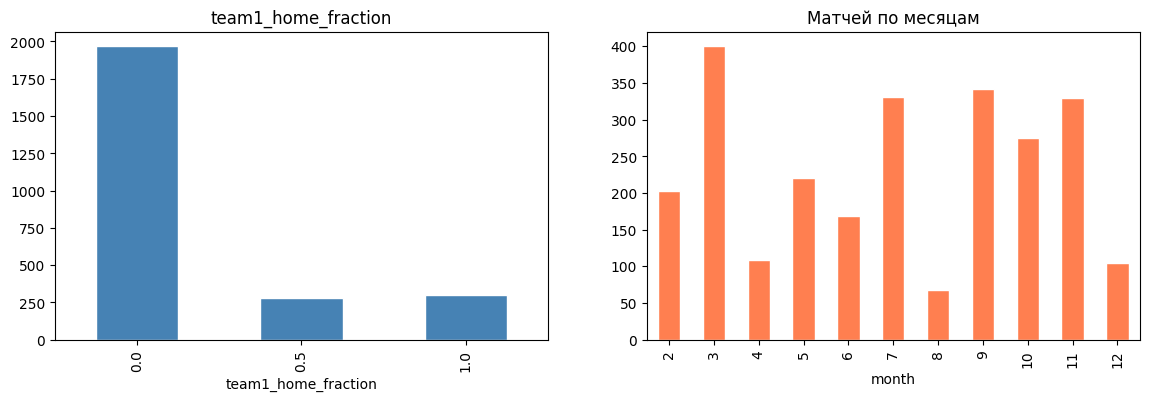

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ctx["team1_home_fraction"].value_counts().sort_index().plot.bar(ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("team1_home_fraction")

ctx["month"].value_counts().sort_index().plot.bar(ax=axes[1], color="coral", edgecolor="white")
axes[1].set_title("Матчей по месяцам")
plt.show()

In [6]:
out_path = FEATURES / "context.csv"
ctx.to_csv(out_path, index=False)